Ce notebook a pour but de realiser quelques analyses descriptives avant de commencer d entrainer le modele

Dans un premier temps on va analyser la repartition des % de victoires des equipes

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_DIR = Path("../data")

df = pd.read_csv(DATA_DIR / "NBA_ML_Dataset.csv")

In [3]:
#Apercu general

print(df.shape)
print(df.describe())

(1462, 284)
            season   playoffs_x          g_x          mp_x  fg_per_100_poss  \
count  1462.000000  1462.000000  1462.000000   1462.000000      1462.000000   
mean   2001.331053     0.556088    80.538988  19462.633379        40.649453   
std      15.123352     0.497014     5.907065   1426.999015         1.818540   
min    1974.000000     0.000000    11.000000   2640.000000        34.700000   
25%    1989.000000     0.000000    82.000000  19755.000000        39.300000   
50%    2002.000000     1.000000    82.000000  19805.000000        40.600000   
75%    2014.000000     1.000000    82.000000  19855.000000        42.000000   
max    2026.000000     1.000000    84.000000  20460.000000        46.700000   

       fga_per_100_poss   fg_percent  x3p_per_100_poss  x3pa_per_100_poss  \
count       1462.000000  1462.000000       1343.000000        1343.000000   
mean          87.768878     0.463288          6.329039          17.889799   
std            2.293504     0.020498         

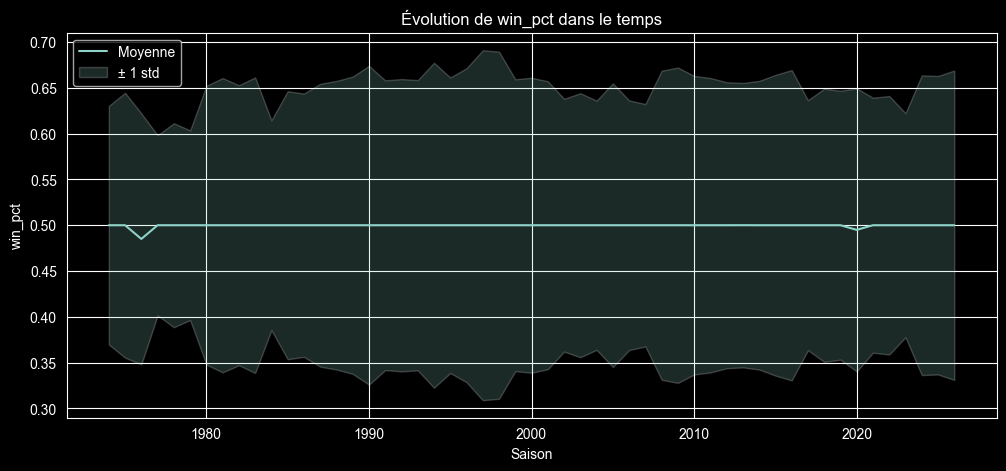

In [4]:
#Evolutaion de win_pct (soit la variable cible) dans le temps

import matplotlib.pyplot as plt

# Moyenne et dispersion de win_pct par saison
win_by_season = df.groupby('season')['win_pct'].agg(['mean', 'std', 'min', 'max'])

plt.figure(figsize=(12,5))
plt.plot(win_by_season.index, win_by_season['mean'], label='Moyenne')
plt.fill_between(win_by_season.index,
                  win_by_season['mean'] - win_by_season['std'],
                  win_by_season['mean'] + win_by_season['std'],
                  alpha=0.2, label='± 1 std')
plt.xlabel('Saison')
plt.ylabel('win_pct')
plt.title('Évolution de win_pct dans le temps')
plt.legend()
plt.show()

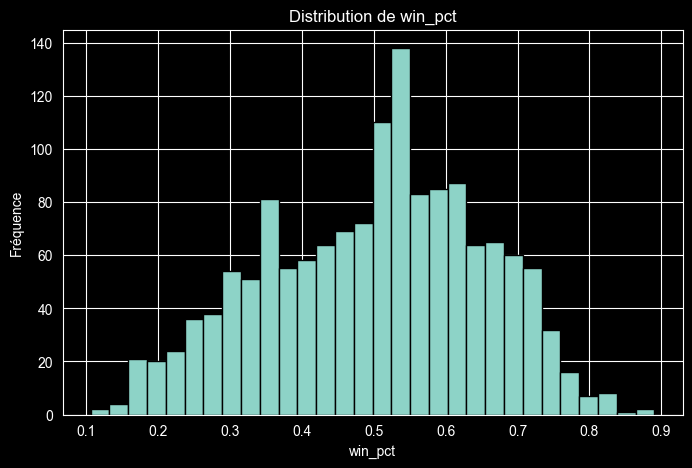

In [5]:
plt.figure(figsize=(8,5))
df['win_pct'].hist(bins=30, edgecolor='black')
plt.xlabel('win_pct')
plt.ylabel('Fréquence')
plt.title('Distribution de win_pct')
plt.show()

win_pct                 1.000000
playoffs_x              0.779295
playoffs_y              0.779295
all_nba_score           0.625744
all_star_score          0.621341
                          ...   
opp_ast_per_100_poss   -0.373147
opp_fg_per_100_poss    -0.375933
opp_blk_per_100_poss   -0.428956
opp_pts_per_100_poss   -0.441768
opp_fg_percent         -0.482362
Name: win_pct, Length: 277, dtype: float64


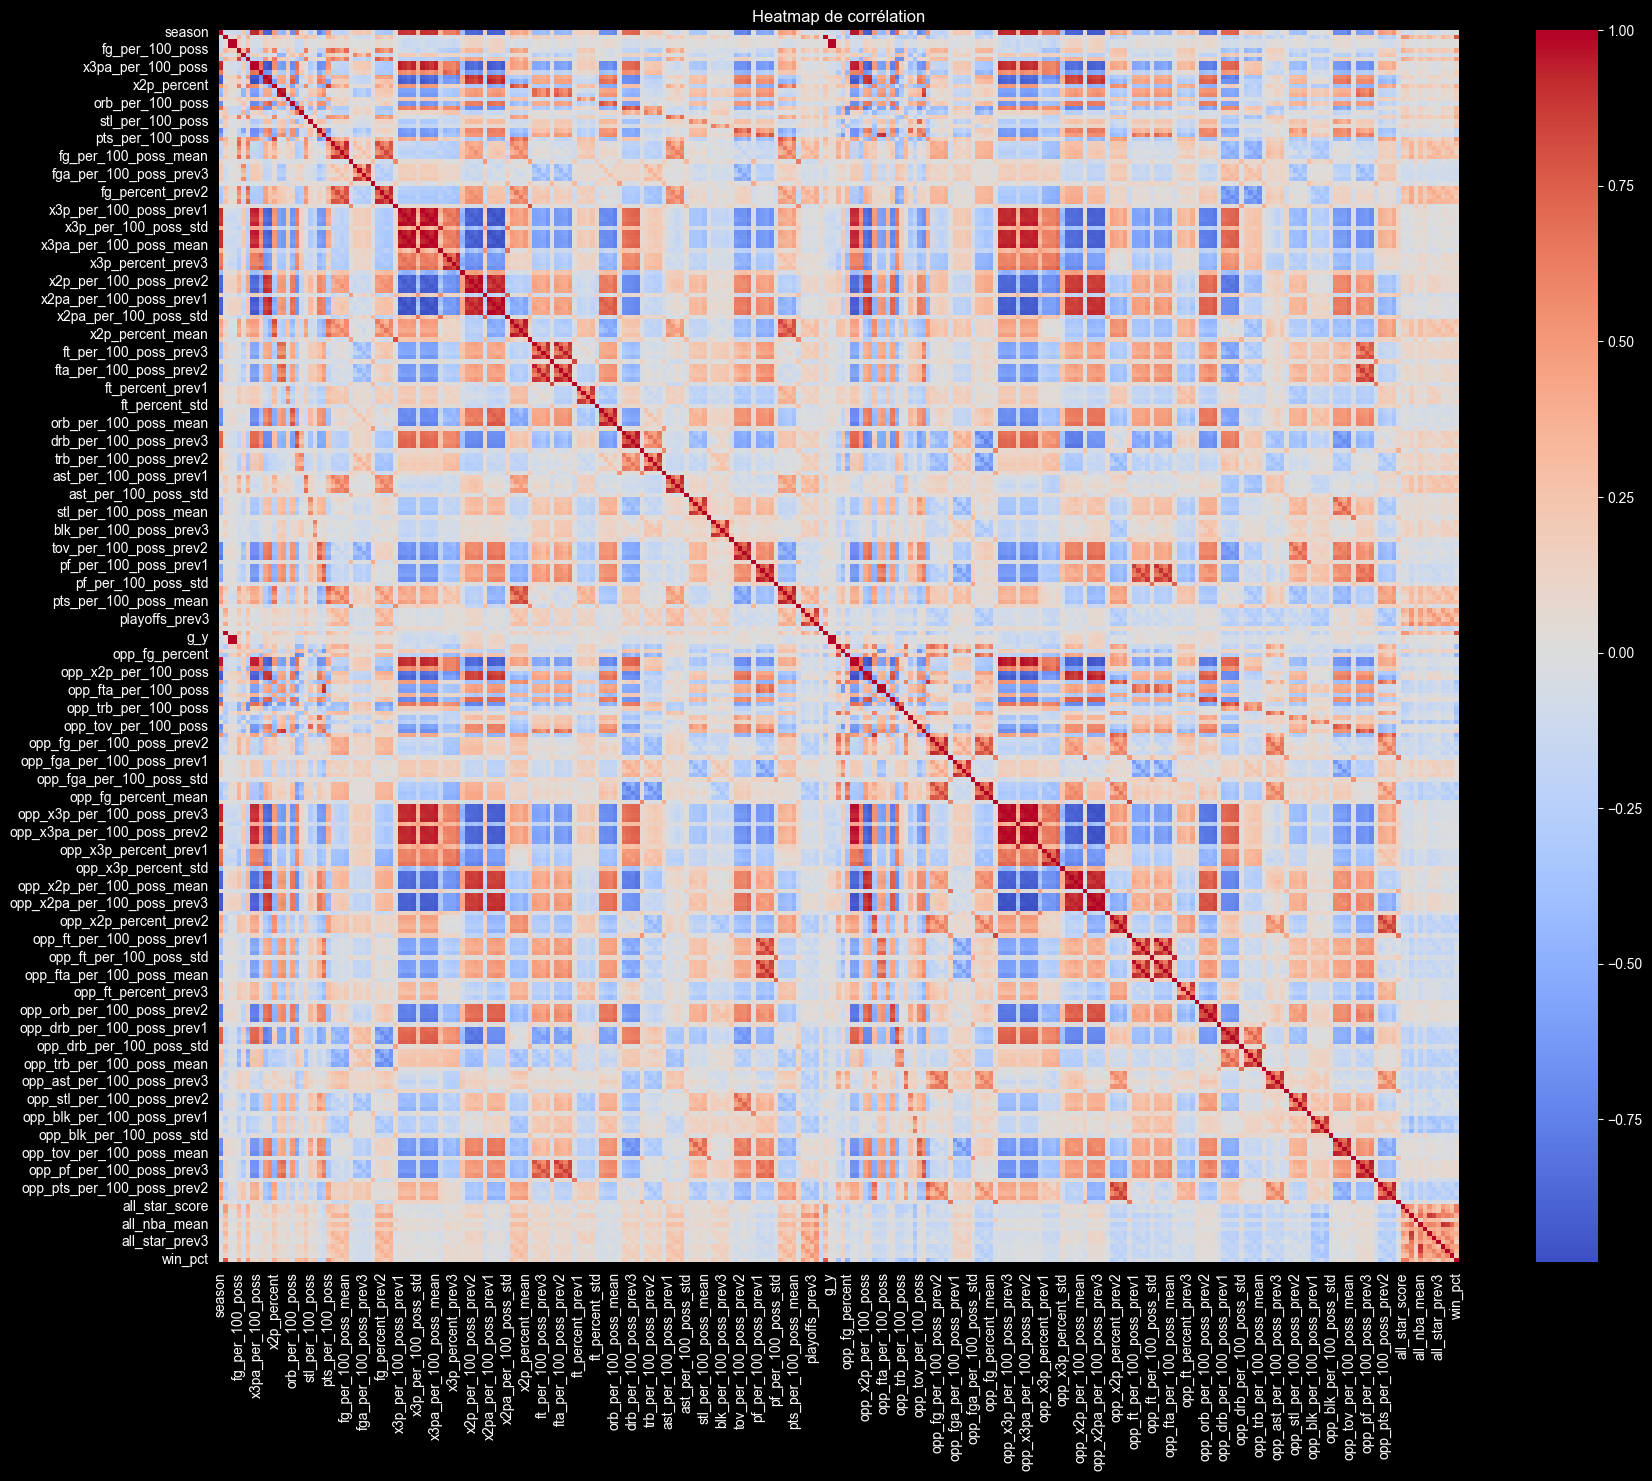

In [6]:
# Corrélation de toutes les colonnes numériques avec win_pct
corr = df.corr(numeric_only=True)['win_pct'].sort_values(ascending=False)
print(corr)

import seaborn as sns

plt.figure(figsize=(20,16))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Heatmap de corrélation')
plt.show()

In [7]:
import numpy as np
import pandas as pd

corr_matrix = df.corr(numeric_only=True)

# Masque : garde uniquement le triangle supérieur (sans diagonale) -> évite doublons A-B/B-A
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

corr_pairs = (
    corr_matrix
    .where(mask)
    .stack()
    .reset_index()
)
corr_pairs.columns = ["var_1", "var_2", "correlation"]

# Filtrer les corrélations fortes
high_corr = corr_pairs[corr_pairs["correlation"].abs() > 0.8].copy()
high_corr["abs_corr"] = high_corr["correlation"].abs()
high_corr = high_corr.sort_values("abs_corr", ascending=False).drop(columns="abs_corr")

print(high_corr.to_string())
print(f"\nNombre de paires trouvées : {len(high_corr)}")

                             var_1                        var_2  correlation
690                            g_x                          g_y     1.000000
968                           mp_x                         mp_y     1.000000
412                     playoffs_x                   playoffs_y     1.000000
557                            g_x                         mp_x     0.998907
967                           mp_x                          g_y     0.998907
691                            g_x                         mp_y     0.998907
37809                          g_y                         mp_y     0.998907
49211    opp_x3p_per_100_poss_mean   opp_x3pa_per_100_poss_mean     0.998628
11959        x3p_per_100_poss_mean       x3pa_per_100_poss_mean     0.997505
39199         opp_x3p_per_100_poss        opp_x3pa_per_100_poss     0.997271
48377   opp_x3p_per_100_poss_prev1  opp_x3pa_per_100_poss_prev1     0.997117
48655   opp_x3p_per_100_poss_prev2  opp_x3pa_per_100_poss_prev2     0.996961

On voit avec le graphe et ce tableau que beaucoup de variables sont correlees, de maniere logique par exemple une equipe tirant beaucoup de 3 pts en rentre beaucoup ainsi on peut garder que une seule des deux variables, avec le % car cel nous permettra de retrouver l information voulue. On peut ainsi faire de meme avec les autres vairables de tirs.

In [8]:
import pandas as pd
import numpy as np
import re


# ============================================================
# PARAMÈTRES
# ============================================================

CORR_THRESHOLD = 0.90


# ============================================================
# IDENTIFIER LA FAMILLE D'UNE VARIABLE
# ============================================================

def get_family(col):

    # Retirer le préfixe opponent
    col = re.sub(r"^opp_", "", col)

    # Retirer le suffixe temporel
    col = re.sub(
        r"_(prev1|prev2|prev3|mean|std)$",
        "",
        col
    )

    return col


# ============================================================
# IDENTIFIER L'HORIZON
# ============================================================

def get_horizon(col):

    match = re.search(
        r"_(prev1|prev2|prev3|mean|std)$",
        col
    )

    if match:
        return match.group(1)

    return "current"


# ============================================================
# ANALYSE DES CORRÉLATIONS
# ============================================================

def analyze_correlations(
    df,
    threshold=0.90
):

    numeric_cols = df.select_dtypes(
        include=np.number
    ).columns

    corr = df[numeric_cols].corr()

    rows = []

    for i in range(len(numeric_cols)):

        for j in range(i + 1, len(numeric_cols)):

            col1 = numeric_cols[i]
            col2 = numeric_cols[j]

            value = corr.loc[col1, col2]

            if pd.isna(value):
                continue

            abs_corr = abs(value)

            if abs_corr < threshold:
                continue

            family1 = get_family(col1)
            family2 = get_family(col2)

            horizon1 = get_horizon(col1)
            horizon2 = get_horizon(col2)

            same_family = family1 == family2
            same_horizon = horizon1 == horizon2

            # ------------------------------------------------
            # Classification
            # ------------------------------------------------

            if same_family:

                category = "same_statistic"

            elif horizon1 == horizon2:

                category = "different_statistics_same_horizon"

            else:

                category = "different_statistics_different_horizon"

            rows.append({
                "variable_1": col1,
                "variable_2": col2,
                "correlation": value,
                "abs_correlation": abs_corr,
                "family_1": family1,
                "family_2": family2,
                "horizon_1": horizon1,
                "horizon_2": horizon2,
                "category": category
            })

    result = pd.DataFrame(rows)

    if len(result) > 0:

        result = result.sort_values(
            "abs_correlation",
            ascending=False
        ).reset_index(drop=True)

    return result

In [9]:
corr_analysis = analyze_correlations(
    df,
    threshold=0.90
)

display(corr_analysis)

,variable_1,variable_2,correlation,abs_correlation,family_1,family_2,horizon_1,horizon_2,category
0,mp_x,mp_y,1.000000,1.000000,mp_x,mp_y,current,current,different_statistics_same_horizon
1,g_x,g_y,1.000000,1.000000,g_x,g_y,current,current,different_statistics_same_horizon
2,g_x,mp_x,0.998907,0.998907,g_x,mp_x,current,current,different_statistics_same_horizon
3,g_x,mp_y,0.998907,0.998907,g_x,mp_y,current,current,different_statistics_same_horizon
4,g_y,mp_y,0.998907,0.998907,g_y,mp_y,current,current,different_statistics_same_horizon
...,...,...,...,...,...,...,...,...,...
539,x2pa_per_100_poss,opp_x2pa_per_100_poss_prev1,0.900582,0.900582,x2pa_per_100_poss,x2pa_per_100_poss,current,prev1,same_statistic
540,x3p_per_100_poss_prev2,opp_x2pa_per_100_poss_prev2,-0.900545,0.900545,x3p_per_100_poss,x2pa_per_100_poss,prev2,prev2,different_statistics_same_horizon
541,opp_fga_per_100_poss_prev1,opp_fga_per_100_poss_mean,0.900529,0.900529,fga_per_100_poss,fga_per_100_poss,prev1,mean,same_statistic
542,blk_per_100_poss_prev1,blk_per_100_poss_mean,0.900246,0.900246,blk_per_100_poss,blk_per_100_poss,prev1,mean,same_statistic


In [10]:
display(
    corr_analysis[
        corr_analysis["category"]
        == "different_statistics_same_horizon"
    ]
)

,variable_1,variable_2,correlation,abs_correlation,family_1,family_2,horizon_1,horizon_2,category
0,mp_x,mp_y,1.000000,1.000000,mp_x,mp_y,current,current,different_statistics_same_horizon
1,g_x,g_y,1.000000,1.000000,g_x,g_y,current,current,different_statistics_same_horizon
2,g_x,mp_x,0.998907,0.998907,g_x,mp_x,current,current,different_statistics_same_horizon
3,g_x,mp_y,0.998907,0.998907,g_x,mp_y,current,current,different_statistics_same_horizon
4,g_y,mp_y,0.998907,0.998907,g_y,mp_y,current,current,different_statistics_same_horizon
...,...,...,...,...,...,...,...,...,...
518,opp_x3p_per_100_poss_prev2,opp_x2p_per_100_poss_prev2,-0.902993,0.902993,x3p_per_100_poss,x2p_per_100_poss,prev2,prev2,different_statistics_same_horizon
526,x2p_per_100_poss_mean,opp_x2pa_per_100_poss_mean,0.902335,0.902335,x2p_per_100_poss,x2pa_per_100_poss,mean,mean,different_statistics_same_horizon
537,x2p_per_100_poss_mean,opp_x3pa_per_100_poss_mean,-0.900833,0.900833,x2p_per_100_poss,x3pa_per_100_poss,mean,mean,different_statistics_same_horizon
540,x3p_per_100_poss_prev2,opp_x2pa_per_100_poss_prev2,-0.900545,0.900545,x3p_per_100_poss,x2pa_per_100_poss,prev2,prev2,different_statistics_same_horizon


In [11]:
# Colonnes doublonnées provenant des merges
duplicate_merge_cols = [
    "g_y",
    "mp_y",
    "playoffs_y",
]

duplicate_merge_cols = [
    c for c in duplicate_merge_cols
    if c in df.columns
]

df = df.drop(columns=duplicate_merge_cols)

In [12]:
import pandas as pd
import numpy as np
import re


def get_family(col):

    # enlever opp_
    col = re.sub(r"^opp_", "", col)

    # enlever horizon temporel
    col = re.sub(
        r"_(prev1|prev2|prev3|mean|std)$",
        "",
        col
    )

    return col


def get_horizon(col):

    match = re.search(
        r"_(prev1|prev2|prev3|mean|std)$",
        col
    )

    if match:
        return match.group(1)

    return "current"


def correlation_report(
    df,
    threshold=0.90
):

    numeric_cols = df.select_dtypes(
        include=np.number
    ).columns

    corr = df[numeric_cols].corr()

    results = []

    for i in range(len(numeric_cols)):

        for j in range(i + 1, len(numeric_cols)):

            col1 = numeric_cols[i]
            col2 = numeric_cols[j]

            c = corr.iloc[i, j]

            if pd.isna(c):
                continue

            if abs(c) < threshold:
                continue

            results.append({

                "variable_1": col1,

                "variable_2": col2,

                "correlation": c,

                "abs_correlation": abs(c),

                "family_1": get_family(col1),

                "family_2": get_family(col2),

                "horizon_1": get_horizon(col1),

                "horizon_2": get_horizon(col2),

            })

    result = pd.DataFrame(results)

    if len(result) > 0:
        result = result.sort_values(
            "abs_correlation",
            ascending=False
        ).reset_index(drop=True)

    return result

In [13]:
corr_report = correlation_report(
    df,
    threshold=0.90
)

display(corr_report)

,variable_1,variable_2,correlation,abs_correlation,family_1,family_2,horizon_1,horizon_2
0,g_x,mp_x,0.998907,0.998907,g_x,mp_x,current,current
1,opp_x3p_per_100_poss_mean,opp_x3pa_per_100_poss_mean,0.998628,0.998628,x3p_per_100_poss,x3pa_per_100_poss,mean,mean
2,x3p_per_100_poss_mean,x3pa_per_100_poss_mean,0.997505,0.997505,x3p_per_100_poss,x3pa_per_100_poss,mean,mean
3,opp_x3p_per_100_poss,opp_x3pa_per_100_poss,0.997271,0.997271,x3p_per_100_poss,x3pa_per_100_poss,current,current
4,opp_x3p_per_100_poss_prev1,opp_x3pa_per_100_poss_prev1,0.997117,0.997117,x3p_per_100_poss,x3pa_per_100_poss,prev1,prev1
...,...,...,...,...,...,...,...,...
534,x2pa_per_100_poss,opp_x2pa_per_100_poss_prev1,0.900582,0.900582,x2pa_per_100_poss,x2pa_per_100_poss,current,prev1
535,x3p_per_100_poss_prev2,opp_x2pa_per_100_poss_prev2,-0.900545,0.900545,x3p_per_100_poss,x2pa_per_100_poss,prev2,prev2
536,opp_fga_per_100_poss_prev1,opp_fga_per_100_poss_mean,0.900529,0.900529,fga_per_100_poss,fga_per_100_poss,prev1,mean
537,blk_per_100_poss_prev1,blk_per_100_poss_mean,0.900246,0.900246,blk_per_100_poss,blk_per_100_poss,prev1,mean


In [14]:
DROP_STATS = [
    "x3p",
    "x2p",
    "ft",
]

In [15]:
def drop_stat_families(df, stats):

    columns_to_drop = []

    for col in df.columns:

        base = re.sub(
            r"^(opp_)?",
            "",
            col
        )

        base = re.sub(
            r"_(prev1|prev2|prev3|mean|std)$",
            "",
            base
        )

        # x3p_per_100_poss
        # x2p_per_100_poss
        # ft_per_100_poss

        for stat in stats:

            if (
                base == f"{stat}_per_100_poss"
                or base.startswith(
                    f"{stat}_per_100_poss"
                )
            ):
                columns_to_drop.append(col)

    columns_to_drop = list(
        dict.fromkeys(columns_to_drop)
    )

    return df.drop(
        columns=columns_to_drop,
        errors="ignore"
    ), columns_to_drop

In [16]:
dataset_reduced, removed = drop_stat_families(
    df,
    DROP_STATS
)

print("Variables supprimées :")
for col in removed:
    print(col)

Variables supprimées :
x3p_per_100_poss
x2p_per_100_poss
ft_per_100_poss
x3p_per_100_poss_prev1
x3p_per_100_poss_prev2
x3p_per_100_poss_prev3
x3p_per_100_poss_mean
x3p_per_100_poss_std
x2p_per_100_poss_prev1
x2p_per_100_poss_prev2
x2p_per_100_poss_prev3
x2p_per_100_poss_mean
x2p_per_100_poss_std
ft_per_100_poss_prev1
ft_per_100_poss_prev2
ft_per_100_poss_prev3
ft_per_100_poss_mean
ft_per_100_poss_std
opp_x3p_per_100_poss
opp_x2p_per_100_poss
opp_ft_per_100_poss
opp_x3p_per_100_poss_prev1
opp_x3p_per_100_poss_prev2
opp_x3p_per_100_poss_prev3
opp_x3p_per_100_poss_mean
opp_x3p_per_100_poss_std
opp_x2p_per_100_poss_prev1
opp_x2p_per_100_poss_prev2
opp_x2p_per_100_poss_prev3
opp_x2p_per_100_poss_mean
opp_x2p_per_100_poss_std
opp_ft_per_100_poss_prev1
opp_ft_per_100_poss_prev2
opp_ft_per_100_poss_prev3
opp_ft_per_100_poss_mean
opp_ft_per_100_poss_std


In [17]:
df.columns.tolist()

['franchise_id',
 'season',
 'lg_x',
 'team_x',
 'abbreviation_x',
 'playoffs_x',
 'g_x',
 'mp_x',
 'fg_per_100_poss',
 'fga_per_100_poss',
 'fg_percent',
 'x3p_per_100_poss',
 'x3pa_per_100_poss',
 'x3p_percent',
 'x2p_per_100_poss',
 'x2pa_per_100_poss',
 'x2p_percent',
 'ft_per_100_poss',
 'fta_per_100_poss',
 'ft_percent',
 'orb_per_100_poss',
 'drb_per_100_poss',
 'trb_per_100_poss',
 'ast_per_100_poss',
 'stl_per_100_poss',
 'blk_per_100_poss',
 'tov_per_100_poss',
 'pf_per_100_poss',
 'pts_per_100_poss',
 'fg_per_100_poss_prev1',
 'fg_per_100_poss_prev2',
 'fg_per_100_poss_prev3',
 'fg_per_100_poss_mean',
 'fg_per_100_poss_std',
 'fga_per_100_poss_prev1',
 'fga_per_100_poss_prev2',
 'fga_per_100_poss_prev3',
 'fga_per_100_poss_mean',
 'fga_per_100_poss_std',
 'fg_percent_prev1',
 'fg_percent_prev2',
 'fg_percent_prev3',
 'fg_percent_mean',
 'fg_percent_std',
 'x3p_per_100_poss_prev1',
 'x3p_per_100_poss_prev2',
 'x3p_per_100_poss_prev3',
 'x3p_per_100_poss_mean',
 'x3p_per_100_p

In [19]:
df.to_csv("../data/NBA_ML_Df_ready.csv", index=False)